# Imports

In [1]:
# =============================================================================
# Imports and environment setup
# =============================================================================
import os
import sys
import time
import logging
import warnings
import tempfile
from pathlib import Path

warnings.filterwarnings("ignore")

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]

# Juno STAligner environment paths fixed during installation.
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["CUDA_HOME"] = "/opt/ohpc/pub/apps/cuda/11.7"
os.environ["STALIGNER_CUDA_LIB"] = "/opt/ohpc/pub/apps/cuda/11.7/targets/x86_64-linux/lib"
os.environ["R_HOME"] = str(CONDA_PREFIX / "lib" / "R")
os.environ.pop("R_USER", None)
os.environ["PYTHONNOUSERSITE"] = "1"

# Make conda, R, and CUDA runtime libraries preferred inside Jupyter.
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX}/lib:"
    f"{CONDA_PREFIX}/lib/R/lib:"
    f"{os.environ['STALIGNER_CUDA_LIB']}:"
    + os.environ.get("LD_LIBRARY_PATH", "")
)

print("Python:", sys.executable)
print("CONDA_PREFIX:", CONDA_PREFIX)
print("CUDA_HOME:", os.environ.get("CUDA_HOME"))
print("R_HOME:", os.environ.get("R_HOME"))
print("LD_LIBRARY_PATH first:", os.environ.get("LD_LIBRARY_PATH", "").split(":")[0])

import h5py
import numpy as np
import pandas as pd
import scipy
import scipy.sparse as sp
import scanpy as sc
import anndata as ad
import torch

from sklearn import metrics as sk_metrics

import rpy2
import rpy2.robjects as ro

import STAligner

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scipy:", scipy.__version__)
print("scanpy:", sc.__version__)
print("anndata:", ad.__version__)
print("torch:", torch.__version__, "cuda available:", torch.cuda.is_available(), "torch cuda:", torch.version.cuda)
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("rpy2:", rpy2.__version__)
print("STAligner:", STAligner.__file__)


Python: /work/dal875013/conda_envs/staligner_env/bin/python
CONDA_PREFIX: /work/dal875013/conda_envs/staligner_env
CUDA_HOME: /opt/ohpc/pub/apps/cuda/11.7
R_HOME: /work/dal875013/conda_envs/staligner_env/lib/R
LD_LIBRARY_PATH first: /work/dal875013/conda_envs/staligner_env/lib
numpy: 1.20.3
pandas: 1.2.3
scipy: 1.5.3
scanpy: 1.9.1
anndata: 0.7.8
torch: 1.9.1+cu111 cuda available: True torch cuda: 11.1
gpu: NVIDIA A30
rpy2: 3.5.16
STAligner: /work/dal875013/projects/mocha/methods/STAligner/STAligner/__init__.py


# USER CONFIGURATION — edit these to match your environment

In [2]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Path to cloned STAligner repo
STALIGNER_ROOT = Path(r"/work/dal875013/projects/mocha/methods/STAligner")

# Path to the folder containing BC_HP SCE_*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/BC_HP_10x/data")

# Output folder for parquet results
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/STAligner/bc_hp_STAligner")

# Subject-level BC_HP grouping from the dataset README.
# Each subject has two replicate spatial transcriptomics samples.
BC_HP_SUBJECT_GROUPS = {
    "subject_11": ["GSM6592054_M7", "GSM6592057_M10"],
    "subject_12": ["GSM6592056_M9", "GSM6592058_M11"],
}

# ----- SUBSET SELECTOR -----------------------------------------------------
# Run only subject 11 and subject 12 for BC_HP.
# First smoke test:
# SUBJECT_GROUPS_TO_RUN = "subject_11"
#
# Requested run:
SUBJECT_GROUPS_TO_RUN = ["subject_11", "subject_12"]

METHOD_NAME = "STAligner"
CLUST_METHOD = "mclust"
NUM_RUNS = 1

# BC_HP benchmark uses fixed 6 spatial domains.
FIXED_NUM_CLUSTERS = 6

# Ground-truth label column in adata.obs.
GT_LABEL_COL = None

# STAligner parameters adapted from the DLPFC tutorial benchmark style.
RAD_CUTOFF = 150
N_TOP_GENES = 5000
KNN_NEIGH = 50


# =============================================================================
# General helpers
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s [%(levelname)s] %(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, mode="w"),
        ],
        force=True,
    )
    logging.info(f"Log file: {log_file}")


def get_device():
    """Return torch.device('cuda:0') if a CUDA GPU is available, else CPU. Logs details."""
    if torch.cuda.is_available():
        dev = torch.device("cuda:0")
        os.environ["CUDA_VISIBLE_DEVICES"] = "0"
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = torch.device("cpu")
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev


def resolve_subject_groups(selector) -> dict:
    """Turn SUBJECT_GROUPS_TO_RUN into a concrete dict: subject_name -> sample_ids."""
    if selector is None or selector == "all":
        return dict(BC_HP_SUBJECT_GROUPS)
    if isinstance(selector, str):
        return {selector: BC_HP_SUBJECT_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        return {name: BC_HP_SUBJECT_GROUPS[name] for name in selector}
    raise ValueError(f"Unrecognized SUBJECT_GROUPS_TO_RUN value: {selector!r}")


def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth layer label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        "layer_guess", "layer_guess_reordered", "layer_guess_reordered_short",
        "Ground Truth", "ground_truth", "GroundTruth",
        "layer", "Layer", "annotation", "Annotation", "z",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c
    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )


def ensure_spatial_obsm(adata, sample_id: str):
    """Ensure adata.obsm['spatial'] exists for STAligner.Cal_Spatial_Net and plotting."""
    if "spatial" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["spatial"]).astype(float)
        return
    if "S" in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"]).astype(float)
        logging.info(f"    [DIAG] {sample_id}: aliased obsm['S'] -> obsm['spatial']")
        return
    xy_candidates = [
        ("x", "y"), ("X", "Y"),
        ("spatial_x", "spatial_y"),
        ("array_col", "array_row"),
        ("pxl_col_in_fullres", "pxl_row_in_fullres"),
        ("imagecol", "imagerow"),
    ]
    for xcol, ycol in xy_candidates:
        if xcol in adata.obs.columns and ycol in adata.obs.columns:
            adata.obsm["spatial"] = adata.obs[[xcol, ycol]].to_numpy(dtype=float)
            logging.info(f"    [DIAG] {sample_id}: created obsm['spatial'] from {xcol}, {ycol}")
            return
    raise KeyError(
        f"{sample_id}: cannot find spatial coordinates. "
        f"Available obsm keys={list(adata.obsm.keys())}, obs columns={list(adata.obs.columns)}"
    )


def clean_label_mask(labels) -> np.ndarray:
    """Keep labeled spots and drop NA/unknown labels."""
    s = pd.Series(labels).astype(object)
    not_na = ~pd.isnull(s)
    lower = s.astype(str).str.lower()
    known = ~lower.isin(["unknown", "nan", "none", "na", ""])
    return (not_na & known).to_numpy()


def get_num_clusters() -> int:
    """Return fixed number of BC_HP clusters."""
    return int(FIXED_NUM_CLUSTERS)


def check_mclust_if_needed():
    """Fail early if mclust clustering is requested but unavailable."""
    if CLUST_METHOD != "mclust":
        return
    try:
        ro.r("library(mclust)")
        logging.info("[CHECK] R package mclust is available")
    except Exception as e:
        raise RuntimeError(
            "Cannot load R package 'mclust'. In staligner_env, run:\n"
            "conda install -n staligner_env -c conda-forge r-mclust -y\n"
            "or install it inside R.\n"
            f"Original error: {e}"
        )


def check_parquet_support():
    """Fail before training if pandas cannot write parquet output."""
    try:
        import pyarrow as pa
        logging.info(f"[CHECK] pyarrow is available: {pa.__version__}")
        return
    except Exception:
        pass
    try:
        import fastparquet  # noqa: F401
        logging.info("[CHECK] fastparquet is available")
        return
    except Exception:
        pass
    raise RuntimeError(
        "Parquet support is missing. Install one parquet engine in staligner_env before running:\n"
        "/work/dal875013/conda_envs/staligner_env/bin/python -m pip install --no-cache-dir --only-binary=:all: pyarrow==10.0.1"
    )


def save_table(df: pd.DataFrame, path_base: Path) -> Path:
    """Save a table as parquet only."""
    parquet_path = path_base.with_suffix(".parquet")
    df.to_parquet(parquet_path, index=False)
    return parquet_path


def read_saved_table(path_base: Path) -> pd.DataFrame:
    """Read a parquet table saved by this notebook."""
    parquet_path = path_base.with_suffix(".parquet")
    if not parquet_path.exists():
        raise FileNotFoundError(f"Cannot find {parquet_path}")
    return pd.read_parquet(parquet_path)


# Data loading  (adapted for .h5ad input)

In [3]:
# =============================================================================
# Data loading  (adapted for new-format .h5ad input with old anndata)
# =============================================================================
# Why this cell is more complicated:
# The STAligner environment intentionally uses old scanpy/anndata versions.
# The QuickSRT h5ad files were written by newer anndata, so sc.read_h5ad may fail
# at newer-encoded groups such as /layers or /obs/z. STAligner only needs X,
# obs labels, var names, and spatial coordinates. The fallback below uses h5py
# to read only those pieces and construct a minimal AnnData object.


def _decode_scalar(x):
    """Decode bytes-like scalar values to str; keep numeric values unchanged."""
    if isinstance(x, bytes):
        return x.decode("utf-8")
    if isinstance(x, np.bytes_):
        return x.astype(str).item()
    return x


def _decode_array(arr):
    """Decode byte string arrays from h5py into normal numpy arrays of str/object."""
    arr = np.asarray(arr)
    if arr.dtype.kind == "S":
        return arr.astype(str)
    if arr.dtype.kind == "O":
        return np.asarray([_decode_scalar(x) for x in arr], dtype=object)
    return arr


def _decode_attr(x):
    """Decode h5py attributes, including arrays of bytes."""
    if x is None:
        return None
    if isinstance(x, (list, tuple)):
        return [_decode_scalar(v) for v in x]
    if isinstance(x, np.ndarray):
        return [_decode_scalar(v) for v in x.tolist()]
    return _decode_scalar(x)


def _h5_node_summary(node) -> str:
    keys = list(node.keys()) if isinstance(node, h5py.Group) else []
    attrs = {str(k): _decode_attr(v) for k, v in getattr(node, "attrs", {}).items()}
    shape = getattr(node, "shape", None)
    dtype = getattr(node, "dtype", None)
    return f"type={type(node).__name__}, shape={shape}, dtype={dtype}, keys={keys[:10]}, attrs={attrs}"


def _read_h5_dataset(node):
    """Read a plain HDF5 dataset and decode byte strings."""
    arr = node[()]
    if isinstance(arr, bytes):
        return arr.decode("utf-8")
    return _decode_array(arr)


def _read_h5_vector(node):
    """
    Read a 1D vector-like h5ad element.
    Handles old/new categorical encodings and several simple wrappers.
    """
    if isinstance(node, h5py.Dataset):
        arr = _read_h5_dataset(node)
        return np.asarray(arr)

    if not isinstance(node, h5py.Group):
        raise TypeError(f"Unsupported HDF5 node: {type(node)}")

    keys = set(node.keys())

    if {"codes", "categories"}.issubset(keys):
        codes = np.asarray(_read_h5_vector(node["codes"])).astype(int)
        categories = np.asarray(_read_h5_vector(node["categories"]), dtype=object)
        out = np.empty(len(codes), dtype=object)
        out[:] = np.nan
        valid = codes >= 0
        out[valid] = categories[codes[valid]]
        return out

    for key in ["values", "value", "data", "array"]:
        if key in keys:
            try:
                return np.asarray(_read_h5_vector(node[key]))
            except Exception:
                pass

    if len(keys) == 1:
        only_key = next(iter(keys))
        return np.asarray(_read_h5_vector(node[only_key]))

    raise ValueError(f"Cannot read vector from HDF5 group: {_h5_node_summary(node)}")


def _read_h5_matrix(node):
    """Read dense or sparse matrix-like h5ad elements."""
    if isinstance(node, h5py.Dataset):
        return _read_h5_dataset(node)

    if not isinstance(node, h5py.Group):
        raise TypeError(f"Unsupported HDF5 node: {type(node)}")

    keys = set(node.keys())
    encoding_type = _decode_attr(node.attrs.get("encoding-type", ""))

    # Newer anndata may store obsm["S"] / obsm["spatial"] as a dataframe group:
    #   attrs: encoding-type="dataframe", column-order=["x", "y"]
    #   children: _index, x, y
    # Old anndata cannot read this, so we manually stack the numeric coordinate columns.
    if encoding_type == "dataframe":
        cols = _decode_attr(node.attrs.get("column-order", []))
        if cols is None:
            cols = []
        if isinstance(cols, str):
            cols = [cols]
        if not cols:
            cols = [k for k in node.keys() if k not in {"_index", "index"}]

        arrays = []
        used_cols = []
        for col in cols:
            if col in {"_index", "index"} or col not in node:
                continue
            try:
                values = np.asarray(_read_h5_vector(node[col]))
                if values.ndim == 1 and np.issubdtype(values.dtype, np.number):
                    arrays.append(values.astype(float))
                    used_cols.append(col)
            except Exception:
                pass

        if len(arrays) >= 2:
            mat = np.column_stack(arrays)
            logging.info(
                f"    [READ] parsed dataframe matrix with columns={used_cols}; shape={mat.shape}"
            )
            return mat

    if {"data", "indices", "indptr"}.issubset(keys):
        data = np.asarray(_read_h5_dataset(node["data"]))
        indices = np.asarray(_read_h5_dataset(node["indices"])).astype(np.int64)
        indptr = np.asarray(_read_h5_dataset(node["indptr"])).astype(np.int64)

        shape = _decode_attr(node.attrs.get("shape", None))
        if shape is None and "shape" in keys:
            shape = _read_h5_dataset(node["shape"])
        shape = tuple(np.asarray(shape).astype(int).tolist())

        if encoding_type == "csc_matrix":
            return sp.csc_matrix((data, indices, indptr), shape=shape).tocsr()
        return sp.csr_matrix((data, indices, indptr), shape=shape)

    # Dense array wrapped in a group.
    for key in ["values", "value", "data", "array", "X"]:
        if key in keys:
            try:
                return _read_h5_matrix(node[key])
            except Exception:
                pass

    if len(keys) == 1:
        only_key = next(iter(keys))
        return _read_h5_matrix(node[only_key])

    raise ValueError(f"Cannot read matrix from HDF5 group: {_h5_node_summary(node)}")


def _is_spatial_matrix(arr, n_obs: int) -> bool:
    """Return True if arr looks like spot coordinates."""
    if sp.issparse(arr):
        return False
    arr = np.asarray(arr)
    if arr.ndim != 2:
        return False
    if arr.shape[0] != n_obs:
        return False
    if arr.shape[1] < 2 or arr.shape[1] > 5:
        return False
    if not np.issubdtype(arr.dtype, np.number):
        return False
    return np.isfinite(arr[:, :2]).any()


def _choose_best_spatial_candidate(candidates):
    """Choose the most likely coordinate matrix from (name, path, arr) candidates."""
    if not candidates:
        return None

    def score(item):
        name, path, _ = item
        s = 0
        text = f"{name} {path}".lower()
        if "spatial" in text:
            s += 100
        if "coord" in text or "coordinate" in text:
            s += 80
        if "/obsm/" in path.lower():
            s += 60
        if name in {"S", "spatial"}:
            s += 50
        if "pxl" in text or "array" in text or "image" in text:
            s += 20
        return s

    return sorted(candidates, key=score, reverse=True)[0]


def _find_spatial_coordinates_in_h5(f: h5py.File, n_obs: int):
    """
    Robustly find coordinates in a newer h5ad file.
    First checks /obsm children; if needed, recursively scans small n_obs x 2-5 arrays.
    """
    candidates = []

    # First pass: explicit /obsm keys. This is the expected place for QuickSRT coordinates.
    if "obsm" in f:
        obsm_keys = list(f["obsm"].keys())
        logging.info(f"    [READ] HDF5 /obsm keys={obsm_keys}")
        for key in obsm_keys:
            node = f["obsm"][key]
            try:
                arr = np.asarray(_read_h5_matrix(node))
                if _is_spatial_matrix(arr, n_obs):
                    candidates.append((key, f"/obsm/{key}", arr[:, :2].astype(float)))
                    logging.info(f"    [READ] candidate coordinates from /obsm/{key}: {arr.shape}")
                else:
                    logging.debug(f"    [READ] /obsm/{key} not coordinate-like: shape={getattr(arr, 'shape', None)}")
            except Exception as e:
                logging.warning(f"    [READ] failed to parse /obsm/{key}: {e}")
    else:
        logging.warning("    [READ] HDF5 file has no /obsm group")

    if candidates:
        return _choose_best_spatial_candidate(candidates)

    # Second pass: scan all small matrices that look like spot coordinates.
    # This handles files where the spatial matrix is not named S/spatial.
    def visit(name, node):
        if candidates:
            # Still allow visit to finish cheaply; no hard stop in h5py.visititems.
            pass
        try:
            if isinstance(node, h5py.Dataset):
                shape = getattr(node, "shape", None)
                if shape is not None and len(shape) == 2 and shape[0] == n_obs and 2 <= shape[1] <= 5:
                    arr = np.asarray(_read_h5_dataset(node))
                    if _is_spatial_matrix(arr, n_obs):
                        candidates.append((Path(name).name, f"/{name}", arr[:, :2].astype(float)))
                        logging.info(f"    [READ] candidate coordinates from /{name}: {arr.shape}")
            elif isinstance(node, h5py.Group):
                # Try group-level matrix only for promising names, to avoid heavy accidental reads.
                text = name.lower()
                if any(tok in text for tok in ["obsm", "spatial", "coord", "pxl", "array", "image", "position"]):
                    try:
                        arr = np.asarray(_read_h5_matrix(node))
                        if _is_spatial_matrix(arr, n_obs):
                            candidates.append((Path(name).name, f"/{name}", arr[:, :2].astype(float)))
                            logging.info(f"    [READ] candidate coordinates from /{name}: {arr.shape}")
                    except Exception:
                        pass
        except Exception:
            pass

    f.visititems(visit)

    if candidates:
        return _choose_best_spatial_candidate(candidates)
    return None


def _get_dataframe_index(df_group: h5py.Group, fallback_n: int, preferred_names=()):
    """Read the index of an anndata obs/var dataframe group."""
    index_key = _decode_attr(df_group.attrs.get("_index", None))
    candidates = []
    if index_key is not None:
        candidates.append(index_key)
    candidates.extend(preferred_names)
    candidates.extend(["_index", "index", "obs_names", "var_names"])

    for key in candidates:
        if key in df_group:
            try:
                values = np.asarray(_read_h5_vector(df_group[key])).astype(str)
                if len(values) == fallback_n:
                    return values
            except Exception:
                continue

    return np.asarray([str(i) for i in range(fallback_n)])


def _get_dataframe_columns(df_group: h5py.Group):
    """Return column names from an anndata dataframe group."""
    cols = _decode_attr(df_group.attrs.get("column-order", []))
    if cols is None:
        cols = []
    if isinstance(cols, str):
        cols = [cols]
    seen = set(cols)
    for key in df_group.keys():
        if key not in seen:
            cols.append(key)
            seen.add(key)
    return cols


def _read_minimal_dataframe(df_group: h5py.Group, index_values, needed_columns=None):
    """Read a minimal obs/var dataframe, skipping nonessential columns that old anndata cannot read."""
    index_values = np.asarray(index_values).astype(str)
    n = len(index_values)
    needed_columns = set(needed_columns or [])

    data = {}
    index_key = _decode_attr(df_group.attrs.get("_index", None))
    skip_keys = {index_key, "_index", "index", "obs_names", "var_names", None}

    for col in _get_dataframe_columns(df_group):
        if col in skip_keys or col not in df_group:
            continue
        try:
            values = np.asarray(_read_h5_vector(df_group[col]))
            if values.ndim == 0:
                values = np.repeat(values.item(), n)
            if len(values) != n:
                if col in needed_columns:
                    raise ValueError(f"length {len(values)} != expected {n}")
                continue
            data[col] = values
        except Exception as e:
            if col in needed_columns:
                raise RuntimeError(
                    f"Failed to read required dataframe column {col!r}: {e}. "
                    f"Node summary: {_h5_node_summary(df_group[col])}"
                )
            logging.debug(f"    [READ] skipped dataframe column {col!r}: {e}")

    return pd.DataFrame(data, index=pd.Index(index_values.astype(str), name=None))


def read_h5ad_minimal_for_staligner(h5ad_path: Path):
    """
    Manual fallback reader for QuickSRT h5ad files.
    Returns AnnData with only X, obs labels, var index, and spatial coordinates.
    """
    h5ad_path = Path(h5ad_path)
    with h5py.File(h5ad_path, "r") as f:
        logging.info(f"    [READ] HDF5 root keys={list(f.keys())}")
        X = _read_h5_matrix(f["X"])
        n_obs, n_vars = X.shape

        obs_index = _get_dataframe_index(f["obs"], n_obs, preferred_names=("barcode", "barcodes"))
        var_index = _get_dataframe_index(f["var"], n_vars, preferred_names=("gene_ids", "gene_symbols", "features"))

        obs_needed = [GT_LABEL_COL] if GT_LABEL_COL is not None else []
        obs_extra = [
            "z", "layer", "Layer", "annotation", "Annotation", "Ground Truth",
            "ground_truth", "x", "y", "X", "Y", "array_col", "array_row",
            "pxl_col_in_fullres", "pxl_row_in_fullres", "imagecol", "imagerow",
            "spatial_x", "spatial_y",
        ]
        obs_cols = [c for c in obs_needed + obs_extra if c is not None]
        obs = _read_minimal_dataframe(f["obs"], obs_index, needed_columns=obs_needed)

        for col in obs_cols:
            if col in obs.columns or col not in f["obs"]:
                continue
            try:
                values = np.asarray(_read_h5_vector(f["obs"][col]))
                if len(values) == n_obs:
                    obs[col] = values
            except Exception as e:
                if col == GT_LABEL_COL:
                    raise
                logging.debug(f"    [READ] could not add obs column {col!r}: {e}")

        var = pd.DataFrame(index=pd.Index(var_index.astype(str), name=None))
        adata = ad.AnnData(X=X, obs=obs, var=var)

        coord_candidate = _find_spatial_coordinates_in_h5(f, n_obs)
        if coord_candidate is not None:
            key, path, coords = coord_candidate
            adata.obsm["spatial"] = coords
            adata.obsm["S"] = coords
            logging.info(f"    [READ] using spatial coordinates from {path}; shape={coords.shape}")
        else:
            logging.warning("    [READ] no coordinate matrix found in h5ad; will try obs coordinate columns later")

        return adata


def read_h5ad_legacy_safe(h5ad_path: Path):
    """
    Read a QuickSRT h5ad file safely in the old STAligner environment.
    First try scanpy/anndata; on failure, use a minimal h5py reader.
    """
    h5ad_path = Path(h5ad_path)

    try:
        adata = sc.read_h5ad(h5ad_path)
        if "spatial" not in adata.obsm and "S" in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
        return adata
    except Exception as e:
        logging.warning(f"    [READ] {h5ad_path.name}: sc.read_h5ad failed in old anndata")
        logging.warning(f"    [READ] {h5ad_path.name}: {e}")
        logging.warning(f"    [READ] {h5ad_path.name}: using minimal h5py reader")
        return read_h5ad_minimal_for_staligner(h5ad_path)


# Subject-level data loading

In [4]:
# =============================================================================
# Subject-level data loading
# =============================================================================
def load_one_bc_hp_sample_for_staligner(sample_id: str):
    """
    Load one BC_HP .h5ad sample and build its STAligner spatial graph before concatenation.
    This follows the STAligner BC_HP benchmark logic, but reads your QuickSRT SCE_*.h5ad files.
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"    [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata_tmp = read_h5ad_legacy_safe(h5ad_path)
    adata_tmp.var_names_make_unique(join="++")

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata_tmp.n_obs}, n_vars={adata_tmp.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata_tmp.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata_tmp.obsm.keys())}")

    gt_col = detect_gt_column(adata_tmp)
    label_series = adata_tmp.obs[gt_col].astype(object).copy()
    label_series[pd.isnull(label_series)] = "unknown"

    adata_tmp.obs["Ground Truth"] = label_series.astype("category")
    adata_tmp.obs["layer_guess"] = adata_tmp.obs["Ground Truth"].astype(object)
    adata_tmp.obs["batch_name"] = sample_id
    adata_tmp.obs["sample_id"] = sample_id
    adata_tmp.obs["sample"] = sample_id
    adata_tmp.obs["original_spot_id"] = adata_tmp.obs_names.astype(str)

    n_labeled = int(clean_label_mask(adata_tmp.obs["Ground Truth"]).sum())
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata_tmp.n_obs})"
    )

    ensure_spatial_obsm(adata_tmp, sample_id)

    # Official tutorial makes spot names unique by appending section_id.
    adata_tmp.obs_names = [
        f"{spot_id}_{sample_id}" for spot_id in adata_tmp.obs["original_spot_id"].astype(str)
    ]

    logging.info(f"    [GRAPH] {sample_id}: Cal_Spatial_Net(rad_cutoff={RAD_CUTOFF})")
    STAligner.Cal_Spatial_Net(adata_tmp, rad_cutoff=int(RAD_CUTOFF))
    if "adj" not in adata_tmp.uns:
        raise KeyError(f"{sample_id}: STAligner.Cal_Spatial_Net did not create adata.uns['adj']")

    # Official tutorial-style expression preprocessing.
    n_hvg = min(int(N_TOP_GENES), int(adata_tmp.n_vars))
    logging.info(f"    [HVG] {sample_id}: selecting top {n_hvg} genes")
    try:
        sc.pp.highly_variable_genes(adata_tmp, flavor="seurat_v3", n_top_genes=n_hvg)
    except Exception as e:
        logging.warning(
            f"    [HVG] {sample_id}: seurat_v3 failed ({e}); falling back to flavor='seurat'"
        )
        sc.pp.highly_variable_genes(adata_tmp, flavor="seurat", n_top_genes=n_hvg)

    sc.pp.normalize_total(adata_tmp, target_sum=1e4)
    sc.pp.log1p(adata_tmp)
    adata_tmp = adata_tmp[:, adata_tmp.var["highly_variable"]].copy()

    logging.info(
        f"    [DONE] {sample_id}: after HVG/preprocess n_obs={adata_tmp.n_obs}, n_vars={adata_tmp.n_vars}"
    )
    return adata_tmp, gt_col


def load_bc_hp_subject_group(subject_name: str, sample_ids: list):
    """
    Load and concatenate the BC_HP replicate samples for one subject, matching STAligner's
    multi-sample integration design.

    Returns:
        adata_concat : concatenated AnnData with adata_concat.uns['edgeList']
        gt_cols      : sample_id -> ground-truth column name
    """
    logging.info(f"  [GROUP] Loading {subject_name}: {sample_ids}")

    batch_list = []
    adj_list = []
    gt_cols = {}

    for sample_id in sample_ids:
        adata_sample, gt_col = load_one_bc_hp_sample_for_staligner(sample_id)
        batch_list.append(adata_sample)
        adj_list.append(adata_sample.uns["adj"])
        gt_cols[sample_id] = gt_col

    logging.info(f"  [CONCAT] {subject_name}: concatenating AnnData objects")
    adata_concat = ad.concat(
        batch_list,
        label="sample_name",
        keys=sample_ids,
        join="inner",
        index_unique=None,
    )
    adata_concat.obs["Ground Truth"] = adata_concat.obs["Ground Truth"].astype("category")
    adata_concat.obs["batch_name"] = adata_concat.obs["batch_name"].astype(str)
    adata_concat.obs["sample_name"] = adata_concat.obs["sample_name"].astype(str)

    logging.info(
        f"  [CONCAT] {subject_name}: adata_concat shape={adata_concat.shape}; "
        f"sample counts={adata_concat.obs['batch_name'].value_counts().to_dict()}"
    )

    logging.info(f"  [GRAPH] {subject_name}: building block-diagonal spatial graph")
    adj_concat = sp.block_diag(adj_list, format="csr")
    adata_concat.uns["edgeList"] = adj_concat.nonzero()
    adata_concat.uns["adj"] = adj_concat

    logging.info(
        f"  [GRAPH] {subject_name}: adj shape={adj_concat.shape}, edges={adj_concat.nnz}"
    )
    return adata_concat, gt_cols


# Metrics and subject-level training

In [5]:
# =============================================================================
# Metrics and subject-level training
# =============================================================================
def compute_staligner_metrics(sub_adata, gt_key: str, pred_key: str):
    """
    Compute the same output fields used by the earlier benchmark notebooks:
    ARI, NMI, ACC, DIS.

    ACC follows the SpaCross-style aggregation:
        mean(NMI, HOM, COM)
    DIS is left as NaN because STAligner does not expose CHAOS/PAS utilities directly.
    """
    y_true = sub_adata.obs[gt_key].astype(str).to_numpy()
    y_pred = sub_adata.obs[pred_key].astype(str).to_numpy()

    ARI = float(sk_metrics.adjusted_rand_score(y_true, y_pred))
    NMI = float(sk_metrics.normalized_mutual_info_score(y_true, y_pred))
    HOM = float(sk_metrics.homogeneity_score(y_true, y_pred))
    COM = float(sk_metrics.completeness_score(y_true, y_pred))
    ACC = float(np.mean([NMI, HOM, COM]))

    CHAOS = np.nan
    PAS = np.nan
    DIS = np.nan

    return ARI, NMI, ACC, DIS, HOM, COM, CHAOS, PAS


def train_one_subject_group(
    subject_name: str,
    sample_ids: list,
    adata_concat,
    device,
    run_seed: int,
):
    """
    Run STAligner for one subject group and return sample-level metrics/predictions.
    """
    num_clusters = get_num_clusters()

    logging.info(
        f"  [TRAIN] Starting STAligner | subject={subject_name} | "
        f"samples={sample_ids} | k_clusters={num_clusters} | "
        f"knn_neigh={KNN_NEIGH} | device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    np.random.seed(666 + run_seed)
    torch.manual_seed(666 + run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(666 + run_seed)

    # Official STAligner tutorial core line:
    # adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh=50, device=used_device)
    adata_concat = STAligner.train_STAligner(
        adata_concat,
        verbose=True,
        knn_neigh=int(KNN_NEIGH),
        device=device,
    )

    if "STAligner" not in adata_concat.obsm:
        raise KeyError("STAligner training finished but adata_concat.obsm['STAligner'] was not found")

    logging.info(
        f"  [DIAG] {subject_name}: STAligner embedding shape={adata_concat.obsm['STAligner'].shape}"
    )

    # Official tutorial clustering:
    # STAligner.mclust_R(adata_concat, num_cluster=7, used_obsm='STAligner')
    STAligner.mclust_R(
        adata_concat,
        num_cluster=int(num_clusters),
        used_obsm="STAligner",
    )

    if CLUST_METHOD not in adata_concat.obs.columns:
        raise KeyError(f"Expected clustering column {CLUST_METHOD!r} after mclust_R")

    pred_labels = adata_concat.obs[CLUST_METHOD].astype(str).to_numpy()
    logging.info(
        f"  [DIAG] {subject_name}: cluster sizes="
        f"{pd.Series(pred_labels).value_counts().sort_index().to_dict()}"
    )

    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # Sample-level metrics and predictions.
    for sample_id in sample_ids:
        mask = adata_concat.obs["batch_name"].astype(str).to_numpy() == str(sample_id)
        sample_adata = adata_concat[mask].copy()

        labeled_mask = clean_label_mask(sample_adata.obs["Ground Truth"])
        labeled_sample = sample_adata[labeled_mask].copy()

        ARI, NMI, ACC, DIS, HOM, COM, CHAOS, PAS = compute_staligner_metrics(
            labeled_sample, gt_key="Ground Truth", pred_key=CLUST_METHOD
        )

        metrics = {
            "method": METHOD_NAME,
            "sample": sample_id,
            "run_seed": run_seed,
            "ARI": float(ARI),
            "NMI": float(NMI),
            "ACC": float(ACC),
            "DIS": float(DIS) if not pd.isna(DIS) else np.nan,
            # Allocate group runtime across its samples so sum(running_time_sec)
            # approximates the actual subject-level training time.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "gpu_model": gpu_name,
            "training_unit": subject_name,
            "training_samples": ",".join(sample_ids),
            "subject_running_time_sec": round(elapsed, 2),
            "num_clusters": int(num_clusters),
            "num_spots": int(sample_adata.n_obs),
            "num_labeled_spots": int(labeled_sample.n_obs),
            "num_training_spots": int(adata_concat.n_obs),
            "num_genes_after_concat": int(adata_concat.n_vars),
            "clust_method": CLUST_METHOD,
            "device": str(device),
            "HOM": float(HOM),
            "COM": float(COM),
            "CHAOS": float(CHAOS) if not pd.isna(CHAOS) else np.nan,
            "PAS": float(PAS) if not pd.isna(PAS) else np.nan,
            "rad_cutoff": int(RAD_CUTOFF),
            "n_top_genes": int(N_TOP_GENES),
            "knn_neigh": int(KNN_NEIGH),
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {subject_name}/{sample_id}: "
            f"ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
            f"allocated_time={elapsed / len(sample_ids):.1f}s  "
            f"subject_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            sample_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in sample_adata.obs.columns
            else sample_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "sample": sample_id,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": sample_adata.obs["Ground Truth"].astype(object).to_numpy(),
                    "pred_label": np.asarray(sample_adata.obs[CLUST_METHOD]).astype(str),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df


# Main benchmark loop

In [6]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("STAligner BC_HP Subject-Level Benchmarking Framework")
    logging.info("=" * 72)

    if not STALIGNER_ROOT.exists():
        raise FileNotFoundError(
            f"STALIGNER_ROOT not found: {STALIGNER_ROOT.resolve()}\n"
            f"Clone it with: git clone https://github.com/zhoux85/STAligner.git"
        )

    if str(STALIGNER_ROOT.resolve()) not in sys.path:
        sys.path.insert(0, str(STALIGNER_ROOT.resolve()))

    check_mclust_if_needed()
    check_parquet_support()
    device = get_device()

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] STALIGNER_ROOT = {STALIGNER_ROOT}")
    logging.info(f"[PATHS] DATA_ROOT      = {DATA_ROOT}")
    logging.info(f"[PATHS] OUTPUT_DIR     = {OUTPUT_DIR}")

    subject_groups = resolve_subject_groups(SUBJECT_GROUPS_TO_RUN)
    logging.info(f"[SUBJECTS] Will process {len(subject_groups)} subject group(s): {subject_groups}")
    logging.info(
        f"[SETTINGS] num_runs={NUM_RUNS}  num_clusters={FIXED_NUM_CLUSTERS}  "
        f"rad_cutoff={RAD_CUTOFF}  n_top_genes={N_TOP_GENES}  knn_neigh={KNN_NEIGH}"
    )
    logging.info("[MODE] subject-level multi-sample training; sample-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (subject_name, sample_ids) in enumerate(subject_groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(subject_groups)}] Subject group {subject_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            adata, gt_cols = load_bc_hp_subject_group(
                subject_name=subject_name,
                sample_ids=sample_ids,
            )

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()

                metrics_list, pred_df = train_one_subject_group(
                    subject_name=subject_name,
                    sample_ids=sample_ids,
                    adata_concat=adata_run,
                    device=device,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], GT_LABEL_COL)
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Subject group {subject_name}: {e}")
            failed.append({"training_unit": subject_name, "error": str(e)})
            continue

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
        "training_unit", "training_samples", "subject_running_time_sec",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    # Keep prediction file exactly SpaCross/STG3Net-compatible.
    pred_lead = ["method", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  predictions.parquet -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet -> {perf_path}  ({len(performance):,} rows)")

    logging.info("")
    logging.info("Per-sample metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "subject_running_time_sec",
    ]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}  "
        f"DIS: {performance['DIS'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(
        f"Total subject-level running time: "
        f"{performance[['training_unit', 'run_seed', 'subject_running_time_sec']].drop_duplicates()['subject_running_time_sec'].sum():.1f}s"
    )

    if failed:
        logging.warning(f"\n{len(failed)} subject group(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['training_unit']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


# Execute the benchmark when this cell is run.
run_benchmark()


2026-05-18 00:05:02,643 [INFO] Log file: /home/dal875013/work/projects/mocha/results/STAligner/bc_hp_STAligner/benchmark.log
2026-05-18 00:05:02,644 [INFO] ========================================================================
2026-05-18 00:05:02,645 [INFO] STAligner BC_HP Subject-Level Benchmarking Framework
2026-05-18 00:05:02,645 [INFO] ========================================================================
2026-05-18 00:05:02,689 [WARNING] R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1
Type 'citation("mclust")' for citing this R package in publications.

2026-05-18 00:05:02,691 [INFO] [CHECK] R package mclust is available
2026-05-18 00:05:02,743 [INFO] [CHECK] pyarrow is available: 10.0.1
2026-05-18 00:05:02,744 [INFO] [DEVICE] CUDA available — using cuda:0
2026-05-18 00:05:02,744 [INFO] [DEVICE] GPU name: NVIDIA A3

100%|██████████| 500/500 [00:01<00:00, 285.10it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

 78%|███████▊  | 391/500 [00:02<00:00, 198.93it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [00:03<00:00, 146.61it/s]

2026-05-18 00:05:27,556 [INFO]   [DIAG] subject_12: STAligner embedding shape=(2663, 30)
fitting ...
  |                                                                      |   0%

  |======================================================================| 100%
2026-05-18 00:05:33,235 [INFO]   [DIAG] subject_12: cluster sizes={'1': 515, '2': 1638, '3': 190, '4': 89, '5': 97, '6': 134}
2026-05-18 00:05:33,251 [INFO]   [METRICS] subject_12/GSM6592056_M9: ARI=0.1890  NMI=0.2035  ACC=0.2632  allocated_time=5.7s  subject_time=11.4s  gpu=NVIDIA A30
2026-05-18 00:05:33,269 [INFO]   [METRICS] subject_12/GSM6592058_M11: ARI=0.2607  NMI=0.3939  ACC=0.4043  allocated_time=5.7s  subject_time=11.4s  gpu=NVIDIA A30
2026-05-18 00:05:33,333 [INFO] 
2026-05-18 00:05:33,334 [INFO] ========================================================================
2026-05-18 00:05:33,335 [INFO] SAVED
2026-05-18 00:05:33,335 [INFO] ========================================================================
2026-05-18 00:05:33,336 [INFO]   predictions.parquet -> /home/dal875013/work/projects/mocha/results/STAligner/bc_hp_STAligner/predictions.parquet  (4,629 rows)
2026-05-18 00:05:33,336 [INFO]   p

# Prediction results visualization

2026-05-18 00:05:33,660 [WARNING]     [READ] SCE_GSM6592054_M7.h5ad: sc.read_h5ad failed in old anndata
2026-05-18 00:05:33,661 [WARNING]     [READ] SCE_GSM6592054_M7.h5ad: Above error raised while reading key '/layers' of type <class 'h5py._hl.group.Group'> from /.
2026-05-18 00:05:33,662 [WARNING]     [READ] SCE_GSM6592054_M7.h5ad: using minimal h5py reader
2026-05-18 00:05:33,664 [INFO]     [READ] HDF5 root keys=['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']
2026-05-18 00:05:33,720 [INFO]     [READ] HDF5 /obsm keys=['S']
2026-05-18 00:05:33,722 [INFO]     [READ] parsed dataframe matrix with columns=['x', 'y']; shape=(1596, 2)
2026-05-18 00:05:33,722 [INFO]     [READ] candidate coordinates from /obsm/S: (1596, 2)
2026-05-18 00:05:33,723 [INFO]     [READ] using spatial coordinates from /obsm/S; shape=(1596, 2)


... storing 'z' as categorical


2026-05-18 00:05:33,777 [WARNING]     [READ] SCE_GSM6592057_M10.h5ad: sc.read_h5ad failed in old anndata
2026-05-18 00:05:33,778 [WARNING]     [READ] SCE_GSM6592057_M10.h5ad: Above error raised while reading key '/layers' of type <class 'h5py._hl.group.Group'> from /.
2026-05-18 00:05:33,778 [WARNING]     [READ] SCE_GSM6592057_M10.h5ad: using minimal h5py reader
2026-05-18 00:05:33,781 [INFO]     [READ] HDF5 root keys=['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']
2026-05-18 00:05:33,816 [INFO]     [READ] HDF5 /obsm keys=['S']
2026-05-18 00:05:33,818 [INFO]     [READ] parsed dataframe matrix with columns=['x', 'y']; shape=(370, 2)
2026-05-18 00:05:33,818 [INFO]     [READ] candidate coordinates from /obsm/S: (370, 2)
2026-05-18 00:05:33,819 [INFO]     [READ] using spatial coordinates from /obsm/S; shape=(370, 2)


... storing 'z' as categorical


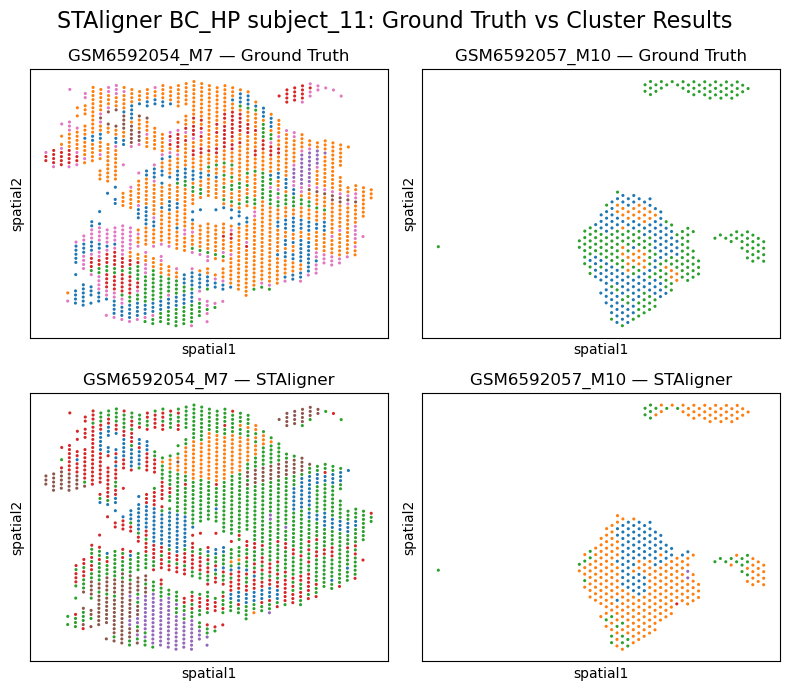

In [7]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/BC_HP_10x/data")
OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/STAligner/bc_hp_STAligner")

SUBJECT_TO_PLOT = "subject_11"

SAMPLES_TO_PLOT = {
    "subject_11": ["GSM6592054_M7", "GSM6592057_M10"],
    "subject_12": ["GSM6592056_M9", "GSM6592058_M11"],
}[SUBJECT_TO_PLOT]

pred_path = OUTPUT_DIR / "predictions.parquet"
if not pred_path.exists():
    raise FileNotFoundError(f"Cannot find {pred_path}. Run the benchmark cell first.")

predictions = pd.read_parquet(pred_path)

fig, axes = plt.subplots(2, len(SAMPLES_TO_PLOT), figsize=(4 * len(SAMPLES_TO_PLOT), 7))
fig.suptitle(f"STAligner BC_HP {SUBJECT_TO_PLOT}: Ground Truth vs Cluster Results", fontsize=16)

for j, sample_id in enumerate(SAMPLES_TO_PLOT):
    pred_slice = predictions[predictions["sample"].astype(str) == sample_id].set_index("spot_id")
    adata = read_h5ad_legacy_safe(DATA_ROOT / f"SCE_{sample_id}.h5ad")

    adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names.astype(str)).values
    adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names.astype(str)).values
    adata.obs["true_label"] = adata.obs["true_label"].astype("category")
    adata.obs["pred_label"] = adata.obs["pred_label"].astype("category")

    if "spatial" not in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

    sc.pl.embedding(
        adata, basis="spatial", color="true_label",
        ax=axes[0, j], show=False, title=f"{sample_id} — Ground Truth", s=20,
        legend_loc=None,
    )
    sc.pl.embedding(
        adata, basis="spatial", color="pred_label",
        ax=axes[1, j], show=False, title=f"{sample_id} — STAligner", s=20,
        legend_loc=None,
    )
    axes[0, j].invert_yaxis()
    axes[1, j].invert_yaxis()

plt.tight_layout()
plt.show()


# Running results summary

In [8]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/home/dal875013/work/projects/mocha/results/STAligner/bc_hp_STAligner")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "subject_running_time_sec",
    "clust_method", "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All STAligner subject-level BC_HP results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary = performance[["ARI", "NMI", "ACC", "DIS", "running_time_sec"]].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Subject-level runtime =====")
runtime = performance[["training_unit", "run_seed", "subject_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total Subject-level runtime: {runtime['subject_running_time_sec'].sum():.2f} sec")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']} ({best['training_unit']})  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']} ({worst['training_unit']})  ARI={worst['ARI']:.4f}")


===== All STAligner subject-level BC_HP results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,num_clusters,num_spots,num_labeled_spots,running_time_sec,subject_running_time_sec,clust_method,gpu_model
0,subject_11,GSM6592054_M7,0,0.164308,0.284821,0.287017,NaN,6,1596,1390,7.64,15.27,mclust,NVIDIA A30
1,subject_11,GSM6592057_M10,0,0.245011,0.223446,0.232834,NaN,6,370,167,7.64,15.27,mclust,NVIDIA A30
2,subject_12,GSM6592056_M9,0,0.188976,0.203498,0.263224,NaN,6,1258,1064,5.70,11.40,mclust,NVIDIA A30
3,subject_12,GSM6592058_M11,0,0.260656,0.393929,0.404274,NaN,6,1405,1118,5.70,11.40,mclust,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,running_time_sec
count,4.000000,4.000000,4.000000,0.0,4.00000
mean,0.214738,0.276424,0.296837,NaN,6.67000
std,0.045577,0.085640,0.074979,NaN,1.12006
min,0.164308,0.203498,0.232834,NaN,5.70000
25%,0.182809,0.218459,0.255626,NaN,5.70000
50%,0.216994,0.254134,0.275120,NaN,6.67000
75%,0.248923,0.312098,0.316331,NaN,7.64000
max,0.260656,0.393929,0.404274,NaN,7.64000



===== Mean metrics =====
Mean ARI: 0.2147
Mean NMI: 0.2764
Mean ACC: 0.2968
Mean DIS: nan

===== Subject-level runtime =====


,training_unit,run_seed,subject_running_time_sec
0,subject_11,0,15.27
2,subject_12,0,11.40


Total Subject-level runtime: 26.67 sec

===== Best / worst ARI =====
Best ARI : GSM6592058_M11 (subject_12)  ARI=0.2607
Worst ARI: GSM6592054_M7 (subject_11)  ARI=0.1643
